In [1]:
print("Telecommunication Churn Prediction Study")
print("Based On Data Exported From Kaggle.com")
print("Using Pre-Processing Pipline")

Telecommunication Churn Prediction Study
Based On Data Exported From Kaggle.com
Using Pre-Processing Pipline


In [135]:

# =========================================================
# STEP 1: IMPORT LIBRARIES + DATA
# =========================================================

from google.colab import files
uploaded = files.upload()

Saving churn2.xls to churn2 (1).xls


In [136]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, accuracy_score, precision_score, recall_score, f1_score)
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

In [ ]:
# Read the uploaded file (auto-detect extension)
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
df.head()

In [138]:
# Dictionary explaining each variable in the dataset
column_description = {
    "ID": "Unique identifier for each customer",
    "COLLEGE": "Indicates whether the customer completed college (zero/one)",
    "INCOME": "Customer yearly income in USD",
    "OVERAGE": "Extra charges incurred due to exceeding plan limits",
    "LEFTOVER": "Unused data/credit remaining in the plan",
    "HOUSE": "Value of customer’s house (proxy for financial status)",
    "HANDSET_PRICE": "Price of customer’s mobile device",
    "OVER_15MINS_CALLS_PER_MONTH": "Number of calls per month that exceed 15 minutes",
    "AVERAGE_CALL_DURATION": "Average duration (in minutes) per call",
    "REPORTED_SATISFACTION": "Self-reported satisfaction level with the service",
    "REPORTED_USAGE_LEVEL": "Customer’s perceived usage level",
    "CONSIDERING_CHANGE_OF_PLAN": "Has the customer considered switching plans?",
    "LEAVE": "Target variable (STAY/LEAVE) — whether customer churned"
}

import pandas as pd


# Build dataframe summarizing schema and explanation
schema_df = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Description": [column_description.get(col, "No description available") for col in df.columns]
})

schema_df

,Column Name,Data Type,Description
0,COLLEGE,object,Indicates whether the customer completed colle...
1,INCOME,int64,Customer yearly income in USD
2,OVERAGE,int64,Extra charges incurred due to exceeding plan l...
3,LEFTOVER,int64,Unused data/credit remaining in the plan
4,HOUSE,int64,Value of customer’s house (proxy for financial...
5,HANDSET_PRICE,int64,Price of customer’s mobile device
6,OVER_15MINS_CALLS_PER_MONTH,int64,Number of calls per month that exceed 15 minutes
7,AVERAGE_CALL_DURATION,int64,Average duration (in minutes) per call
8,REPORTED_SATISFACTION,object,Self-reported satisfaction level with the service
9,REPORTED_USAGE_LEVEL,object,Customer’s perceived usage level


In [139]:
target = "LEAVE"
X = df.drop(columns=[target])
y = df[target]

In [140]:
if df[target].dtype == object:
    le = LabelEncoder()
    df[target] = le.fit_transform(df[target])

numeric_cols = df.select_dtypes(include="number").columns
numeric_cols = [c for c in numeric_cols if c != target]

r2_scores = {}

for col in numeric_cols:
    X = df[[col]].values  # single feature (must be 2D)
    y = df[target].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    r2_scores[col] = r2_score(y, y_pred)

print("\nR² for each numeric feature vs target:")
for feature, r2 in sorted(r2_scores.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{feature}: {r2:.4f}")


R² for each numeric feature vs target:
OVERAGE: 0.0553
HOUSE: 0.0446
OVER_15MINS_CALLS_PER_MONTH: 0.0409
INCOME: 0.0093
HANDSET_PRICE: 0.0080
LEFTOVER: 0.0037
AVERAGE_CALL_DURATION: 0.0001


In [6]:
print("\nSummary")

print("\nR² values range from 0 to 1")

print("\n1.0 means the feature perfectly predicts the target")

print("\n0.0 means the feature has no predictive power")

print("\nYour highest R² = 0.0553 (≈ 5.5%), which is extremely low")

print("\nConclusion: No single numeric feature is linearly explaining churn")

print("\nEven the best feature (OVERAGE) explains only 5.5% of churn variation")

print("\nFeature	R² Value	Interpretation")
print("\n~OVERAGE~	0.0553	Weak relationship, but it's the strongest among all numeric features. Customers with more overage minutes may be more likely to churn")
print("\n~HOUSE~	0.0446	Very weak relationship, but indicates that household size might have a minor impact on churn")
print("\n~OVER~_15MINS_CALLS_PER_MONTH	0.0409	Very weak, suggests customers making more long calls might churn slightly more")
print("\n~INCOME~	0.0093	Almost no relationship. Income doesn’t predict churn")
print("\n~HANDSET_PRICE~	0.0080	Almost no relationship. Handset price has little effect on churn")
print("\n~LEFTOVER~	0.0037	No meaningful relationship")
print("\n~AVERAGE_CALL_DURATION~	0.0001	No relationship at all")
print("\n~All features have very low R² values, meaning no single numeric feature alone can explain churn well")

print("\n~The highest (OVERAGE at ~0.055) explains only 5.5% of the variance in churn, which is minimal")

print("\n~This suggests churn is influenced by multiple factors combined, not individually.")


Summary

R² values range from 0 to 1

1.0 means the feature perfectly predicts the target

0.0 means the feature has no predictive power

Your highest R² = 0.0553 (≈ 5.5%), which is extremely low

Conclusion: No single numeric feature is linearly explaining churn

Even the best feature (OVERAGE) explains only 5.5% of churn variation

Feature	R² Value	Interpretation

~OVERAGE~	0.0553	Weak relationship, but it's the strongest among all numeric features. Customers with more overage minutes may be more likely to churn

~HOUSE~	0.0446	Very weak relationship, but indicates that household size might have a minor impact on churn

~OVER~_15MINS_CALLS_PER_MONTH	0.0409	Very weak, suggests customers making more long calls might churn slightly more

~INCOME~	0.0093	Almost no relationship. Income doesn’t predict churn

~HANDSET_PRICE~	0.0080	Almost no relationship. Handset price has little effect on churn

~LEFTOVER~	0.0037	No meaningful relationship

~AVERAGE_CALL_DURATION~	0.0001	No relationship 

In [141]:
# Preprocessing steps
# ---------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [142]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [143]:
# Combine preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [144]:
df = df.drop(columns=["ID"], errors="ignore")


In [145]:
# ---------------------------
#Train-test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Preprocessing pipeline built successfully.")
print("Numeric features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Preprocessing pipeline built successfully.
Numeric features: ['ID', 'INCOME', 'OVERAGE', 'LEFTOVER', 'HOUSE', 'HANDSET_PRICE', 'OVER_15MINS_CALLS_PER_MONTH', 'AVERAGE_CALL_DURATION']
Categorical features: ['COLLEGE', 'REPORTED_SATISFACTION', 'REPORTED_USAGE_LEVEL', 'CONSIDERING_CHANGE_OF_PLAN']


In [148]:
X = pd.DataFrame(X)

# Identify column types
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

print("Numeric cols:", numeric_features)
print("Categorical cols:", categorical_features)

# Preprocessing step
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Numeric cols: [0]
Categorical cols: []


In [51]:
corr = df.corr(numeric_only=True)
corr

,INCOME,OVERAGE,LEFTOVER,HOUSE,HANDSET_PRICE,OVER_15MINS_CALLS_PER_MONTH,AVERAGE_CALL_DURATION
INCOME,1.000000,0.000458,0.006515,-0.010964,0.727200,0.002136,-0.007219
OVERAGE,0.000458,1.000000,-0.003123,0.002412,0.000324,0.770557,0.000653
LEFTOVER,0.006515,-0.003123,1.000000,0.006530,0.004004,-0.010411,-0.660285
HOUSE,-0.010964,0.002412,0.006530,1.000000,-0.007756,0.007410,-0.009359
HANDSET_PRICE,0.727200,0.000324,0.004004,-0.007756,1.000000,0.002680,-0.005190
OVER_15MINS_CALLS_PER_MONTH,0.002136,0.770557,-0.010411,0.007410,0.002680,1.000000,0.007769
AVERAGE_CALL_DURATION,-0.007219,0.000653,-0.660285,-0.009359,-0.005190,0.007769,1.000000


In [7]:
print("~SUMMARY~")

print("\n~Strong Correlated Features~")

print("\n~Income~ is strong correlated with ~Handset price~~")

print("\n~Overage~ is strong correlated with ~over 15min calls per months~~")

print("\n~Leftover~ is strong negatively correlated with ~Average call duration~~")

print("\n~Conclusion~ churn depends on interactions between features, not isolated variables")

~SUMMARY~

~Strong Correlated Features~

~Income~ is strong correlated with ~Handset price~~

~Overage~ is strong correlated with ~over 15min calls per months~~

~Leftover~ is strong negatively correlated with ~Average call duration~~

~Conclusion~ churn depends on interactions between features, not isolated variables


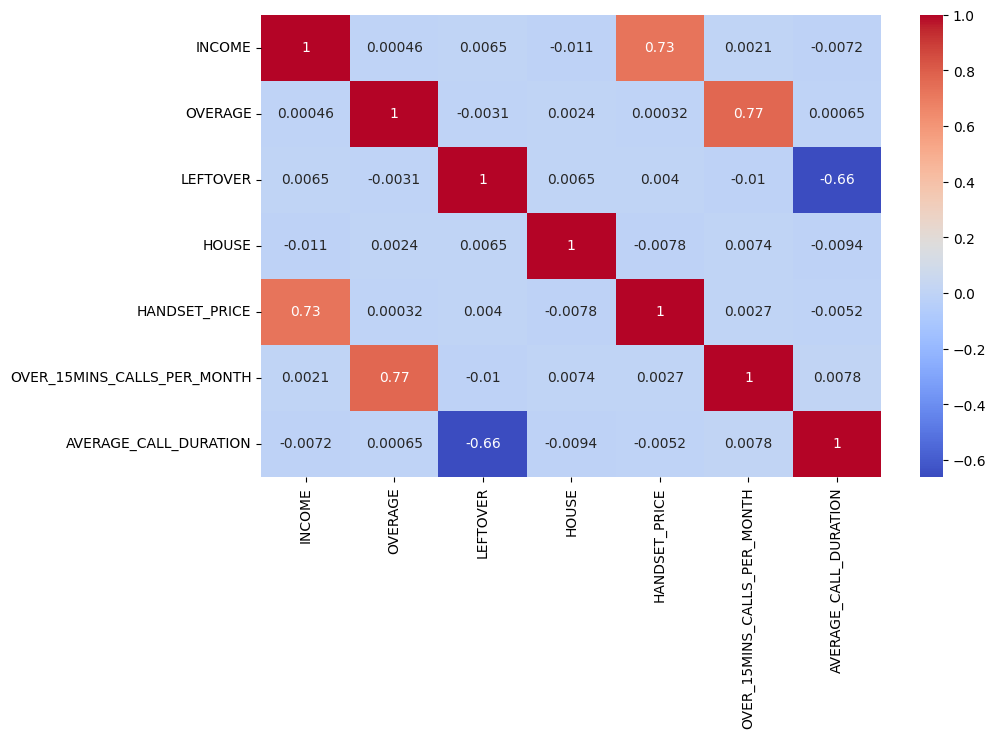

In [52]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [67]:
# =========================================================
# RANDOM FOREST CLASSIFIER WITH PREPROCESSING PIPELINE
# =========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Build model pipeline (reuse preprocess you already defined)
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=42,
        class_weight="balanced"    # churn dataset is usually imbalanced
    ))
])

In [68]:
# Train model
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['ID', 'INCOME', 'OVERAGE', 'LEFTOVER', 'HOUSE', 'HANDSET_PRICE',
       'OVER_15MINS_CALLS_PER_MONTH', 'AVERAGE_CALL_DURATION'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['COLLEGE', 'REPORTED_SATISFACTION', 'REPORTED_USAGE_LEVEL',
       'CONSIDERING_CHANGE_OF_PLAN'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=6,
                                        n_estimators=300, random_state=42))])

In [69]:
# Predict on test data
y_pred = rf_model.predict(X_test)



In [70]:
print("Random Forest Model Completed\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Random Forest Model Completed

Classification Report:
              precision    recall  f1-score   support

       LEAVE       0.69      0.66      0.68      1970
        STAY       0.68      0.71      0.70      2030

    accuracy                           0.69      4000
   macro avg       0.69      0.69      0.69      4000
weighted avg       0.69      0.69      0.69      4000


Confusion Matrix:
[[1303  667]
 [ 587 1443]]


In [9]:
print("\n~SUMMARY~")

print("\n~~Precision (LEAVE = 0.69)~ means that when the customer will leave its correct 69%~")

print("\n~~Recall (LEAVE = 0.66)~ identifies that 66% of cutomers are actually leaving ~ 34% of churners are missed~ ")


~SUMMARY~

~~Precision (LEAVE = 0.69)~ means that when the customer will leave its correct 69%~

~~Recall (LEAVE = 0.66)~ identifies that 66% of cutomers are actually leaving ~ 34% of churners are missed~ 


In [71]:
# =========================================================
# FEATURE IMPORTANCE (INCLUDING ONE-HOT ENCODED FEATURES)
# =========================================================

# Get feature names after preprocessing
encoded_feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()

# Get model importances
importances = rf_model.named_steps["classifier"].feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Important Features:")
feature_importance_df.head(15)


Top 15 Important Features:


,Feature,Importance
4,num__HOUSE,0.323258
2,num__OVERAGE,0.222454
6,num__OVER_15MINS_CALLS_PER_MONTH,0.130560
1,num__INCOME,0.104840
3,num__LEFTOVER,0.072263
5,num__HANDSET_PRICE,0.066145
7,num__AVERAGE_CALL_DURATION,0.041088
0,num__ID,0.016770
8,cat__COLLEGE_one,0.002231
9,cat__COLLEGE_zero,0.002212


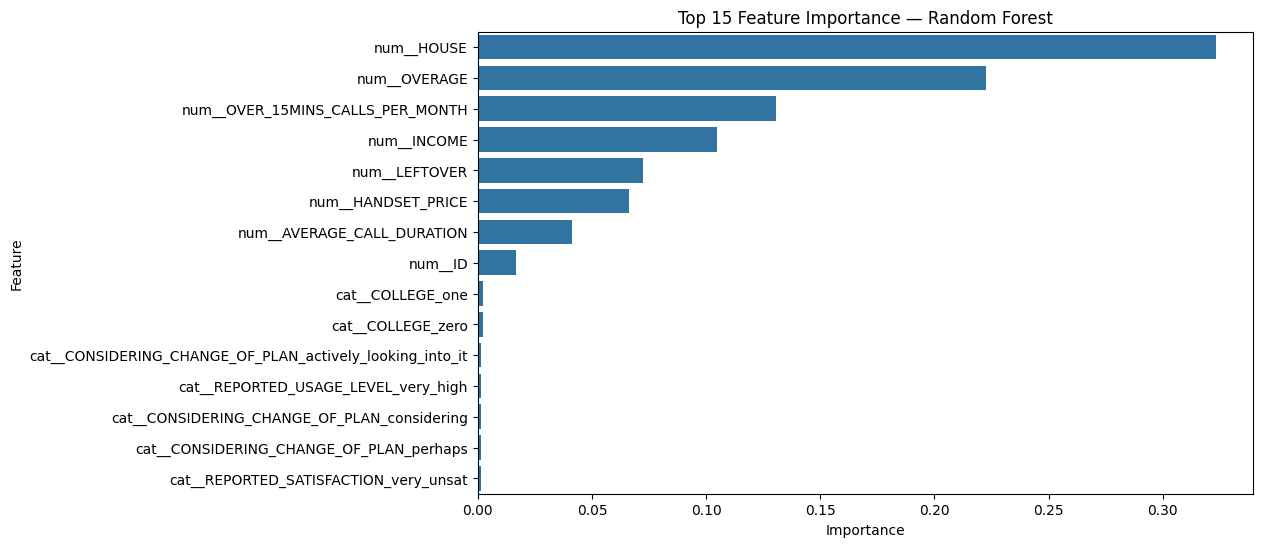

In [72]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importance — Random Forest")
plt.show()

In [73]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Apply preprocessing only (no model step)
X_train_processed = preprocess.fit_transform(X_train)

# 2. Apply SMOTE to oversample minority class
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_processed, y_train)

print("SMOTE applied successfully:")
print("Before:", X_train.shape, "→ After:", X_train_resampled.shape)

SMOTE applied successfully:
Before: (16000, 12) → After: (16236, 25)


In [74]:
# =========================================================
# TRAIN RANDOM FOREST ON OVERSAMPLED DATA
# =========================================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    class_weight=None
)

rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(max_depth=6, n_estimators=300, random_state=42)

In [76]:
# Predict on test set (use preprocess on X_test too)
X_test_processed = preprocess.transform(X_test)
y_pred = rf.predict(X_test_processed)

print("\nNew Classification Report (with SMOTE):")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


New Classification Report (with SMOTE):
              precision    recall  f1-score   support

       LEAVE       0.69      0.66      0.68      1970
        STAY       0.68      0.71      0.70      2030

    accuracy                           0.69      4000
   macro avg       0.69      0.69      0.69      4000
weighted avg       0.69      0.69      0.69      4000


Confusion Matrix:
[[1308  662]
 [ 596 1434]]


In [10]:
print("\n~SUMMARY~")
print("\n~After Applying SMOTE there is no change~")


~SUMMARY~

~After Applying SMOTE there is no change~


In [77]:
# ============================================================
# BUILD MASTER PIPELINE (ENCODING + MODEL)
# ============================================================

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features),
    ]
)

# Logistic Regression Model
log_reg_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=500))
])

# Random Forest Model
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42))
])

In [78]:
# ============================================================
# Train Models
# ============================================================
log_reg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("\nModels trained successfully.\n")


Models trained successfully.



In [82]:
# ============================================================
# Evaluation Reports
# ============================================================
print("Logistic Regression Performance:")
print(classification_report(y_test, log_reg_model.predict(X_test)))

print("Random Forest Performance:")
print(classification_report(y_test, rf_model.predict(X_test)))




Logistic Regression Performance:
              precision    recall  f1-score   support

       LEAVE       0.64      0.61      0.63      1970
        STAY       0.64      0.67      0.65      2030

    accuracy                           0.64      4000
   macro avg       0.64      0.64      0.64      4000
weighted avg       0.64      0.64      0.64      4000

Random Forest Performance:
              precision    recall  f1-score   support

       LEAVE       0.68      0.68      0.68      1970
        STAY       0.69      0.69      0.69      2030

    accuracy                           0.69      4000
   macro avg       0.69      0.69      0.69      4000
weighted avg       0.69      0.69      0.69      4000



In [11]:
print("\n~SUMMARY")
print("\n~Comparing the 2 training models conclude that ~Randon Forest Performance~ is better than ~Logistic Regression Performance~")


~SUMMARY

~Comparing the 2 training models conclude that ~Randon Forest Performance~ is better than ~Logistic Regression Performance~


In [93]:
new_data = pd.read_excel("churn2.xls")




In [107]:
# Make a copy for prediction (remove target column if present)
X_new = new_data.copy()
if 'LEAVE' in X_new.columns:  # or whatever your target column is called
    X_new = X_new.drop('LEAVE', axis=1)

In [108]:
#Predict using trained model (Random Forest)
predictions = rf_model.predict(X_new)
prediction_probabilities = rf_model.predict_proba(X_new)

In [109]:
# Add results to dataframe
new_data['Churn_Prediction'] = predictions
new_data['Probability_Leave'] = prediction_probabilities[:, 1]

In [110]:
# Show output
print(new_data.head())

# (optional) save results to a new file
new_data.to_csv("churn_predictions_output.csv", index=False)
print("Prediction file saved: churn_predictions_output.csv")

   ID COLLEGE  INCOME  OVERAGE  LEFTOVER   HOUSE  HANDSET_PRICE  \
0   1    zero   31953        0         6  313378            161   
1   2     one   36147        0        13  800586            244   
2   3     one   27273      230         0  305049            201   
3   4    zero  120070       38        33  788235            780   
4   5     one   29215      208        85  224784            241   

   OVER_15MINS_CALLS_PER_MONTH  AVERAGE_CALL_DURATION REPORTED_SATISFACTION  \
0                            0                      4                 unsat   
1                            0                      6                 unsat   
2                           16                     15                 unsat   
3                            3                      2                 unsat   
4                           21                      1            very_unsat   

  REPORTED_USAGE_LEVEL CONSIDERING_CHANGE_OF_PLAN  LEAVE Churn_Prediction  \
0               little                       

In [111]:
new_data = pd.read_excel("churn2.xls", engine="xlrd")


In [12]:
print("\nIf ~Probability_Leave~ >= 0.8, ~High Risk~")

print("\nIf ~Probability_Leave~ >= 0.5, ~Medium Risk~")


print("\nThis helps identify customers that might churn even if they didn’t leave yet → actionable insight")


If ~Probability_Leave~ >= 0.8, ~High Risk~

If ~Probability_Leave~ >= 0.5, ~Medium Risk~

This helps identify customers that might churn even if they didn’t leave yet → actionable insight


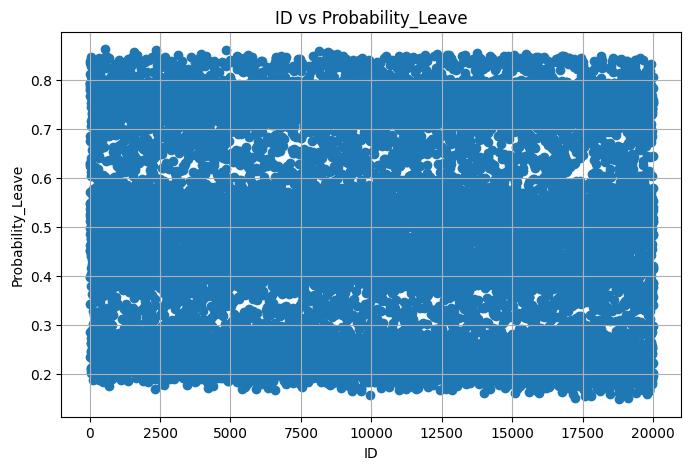

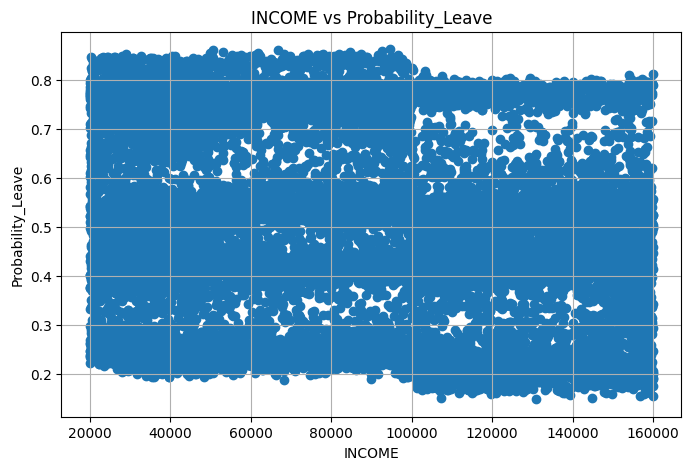

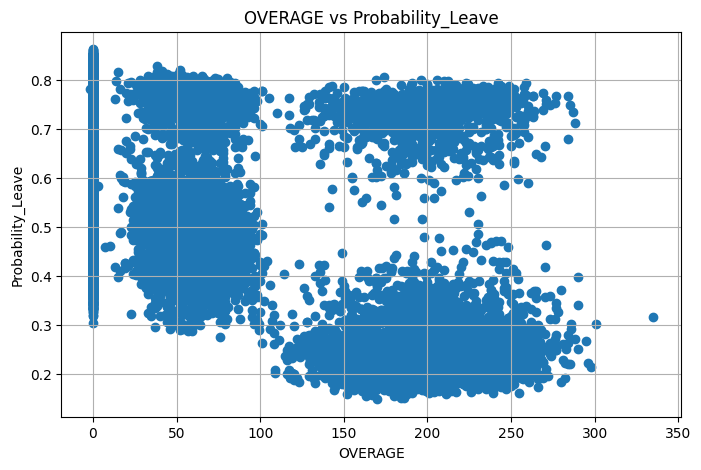

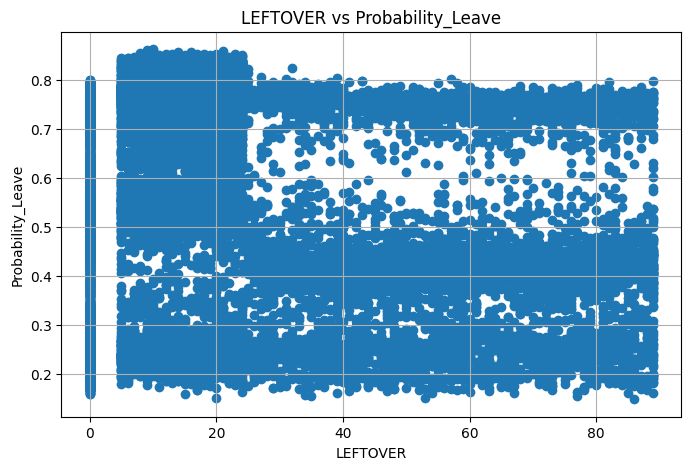

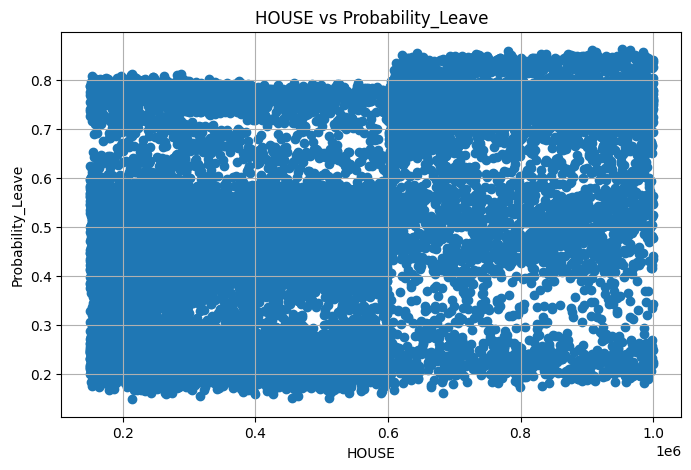

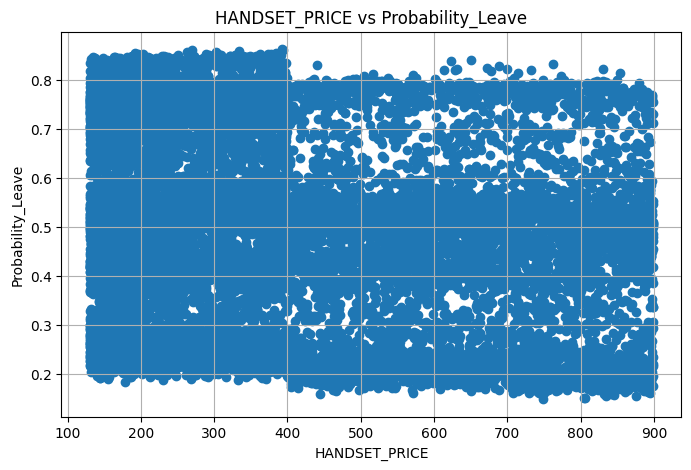

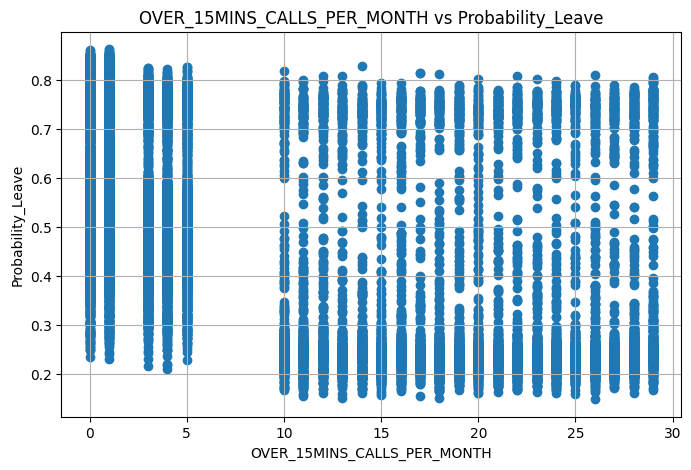

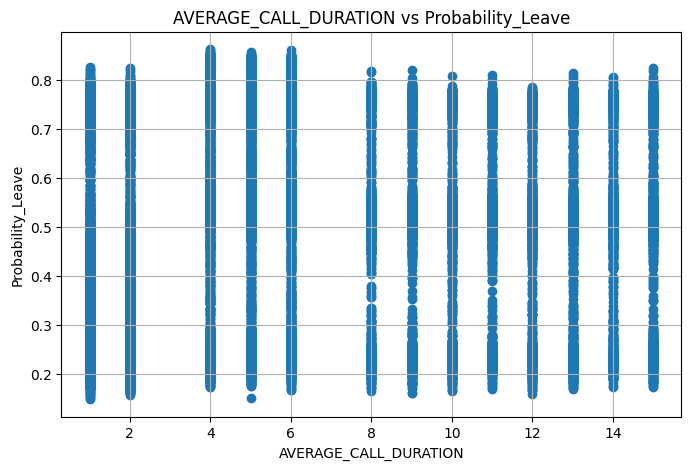

In [116]:
# ==========================================
# REGRESSION-STYLE PLOTS FOR ALL NUMERIC FEATURES
# ==========================================
import matplotlib.pyplot as plt

numeric_cols = new_data.select_dtypes(include="number").columns.tolist()

# loop through numeric columns and plot each vs Probability_Leave
for col in numeric_cols:
    if col != "Probability_Leave":
        plt.figure(figsize=(8, 5))
        plt.scatter(new_data[col], new_data["Probability_Leave"])
        plt.xlabel(col)
        plt.ylabel("Probability_Leave")
        plt.title(f"{col} vs Probability_Leave")
        plt.grid(True)
        plt.show()

In [117]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# =====================================================
#Churn Distribution
# =====================================================
fig1 = px.pie(
    new_data,
    names="Churn_Prediction",
    title="Churn Distribution (STAY vs LEAVE)",
    hole=0.4
)
fig1.show()

In [118]:
# =====================================================
#Histogram of Churn Probability
# =====================================================
fig2 = px.histogram(
    new_data,
    x="Probability_Leave",
    nbins=20,
    title="Churn Probability Distribution"
)
fig2.update_xaxes(title="Probability of Leaving")
fig2.update_yaxes(title="Number of Customers")
fig2.show()